In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd
import json

An example of the training data, consisting of $N$ hadronization events (in the dataset below $N = 10,000$), is:
$$
\boldsymbol{z} = 
  \begin{pmatrix}
    \boldsymbol{z}_1 = 
    \begin{pmatrix} 
        \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1},p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, 									  z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
        \big\{  \texttt{idOld}^{2}, \texttt{idNew}^2, m_T^{h_2}, p_x^{h_2}, p_y, z^{h_2}_{\text{accept}}, z^{1, h_2}_{\text{reject}}, z^{2, h_2}_{\text{reject}}, \cdots, z^{n_{h_2}, h_2}_{\text{reject}} \big\} \\	
        \big\{ \texttt{idOld}^{3}, \texttt{idNew}^3, m_T^{h_3}, p_x^{h_3}, p_y^{h_3}, z^{h_3}_{\text{accept}}, z^{1, h_3}_{\text{reject}}, z^{2, h_3}_{\text{reject}}, \cdots, z^{n_{h_3}, h_3}_{\text{reject}} \big\} 
        \end{pmatrix}_1 \\
    \boldsymbol{z}_2 = 
    \begin{pmatrix} 
      \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
      \vdots \\	
      \big\{ \texttt{idOld}^{4}, \texttt{idNew}^4, m_T^{h_4}, p_x^{h_4}, p_y^{h_4}, z^{h_4}_{\text{accept}}, z^{1, h_4}_{\text{reject}}, z^{2, h_4}_{\text{reject}}, \cdots, z^{n_{h_4}, h_4}_{\text{reject}} \big\} 
      \end{pmatrix}_2 \\
      \vdots \\
    \boldsymbol{z}_N = \cdots
  \end{pmatrix},
$$
$$
\boldsymbol{y}_\text{sim} = 
  \begin{pmatrix}
    \boldsymbol{y}_1 = N_{h,1} = 3\\
    \boldsymbol{y}_2 = N_{h,2} = 4 \\
    \vdots \\
    \boldsymbol{y}_N = N_{h,N} = 2
\end{pmatrix}
$$
Note that each array $\boldsymbol{z}_i$ is zero-padded to a fixed length of size $105$ and each accept-reject array is zero-padded to a fixed length of size $101$ (the maximum number of rejections is 100).

The hadrons dataset consists of an array:

$X =
\begin{pmatrix}
\mathbf{x}_1 =
\begin{pmatrix}
\{ p_x^{(1)},\ p_y^{(1)},\ p_z^{(1)},\ E^{(1)}?,\ m^{(1)}?,\ \mathrm{PDG}^{(1)}? \} \\
\{ p_x^{(2)},\ p_y^{(2)},\ p_z^{(2)},\ E^{(2)},\ m^{(2)},\ \mathrm{PDG}^{(2)} \} \\
\vdots \\
\{ p_x^{(N_1)},\ p_y^{(N_1)},\ p_z^{(N_1)},\ E^{(N_1)},\ m^{(N_1)},\ \mathrm{PDG}^{(N_1)} \}\\
\{0,\dots,0 \}\\
\vdots\\
\{0,\dots,0 \}\\
\end{pmatrix}_1
\\[1em]
\mathbf{x}_2 =
\begin{pmatrix}
\{ p_x^{(1)},\ p_y^{(1)},\ p_z^{(1)},\ E^{(1)},\ m^{(1)},\ \mathrm{PDG}^{(1)} \} \\
\vdots \\
\{ p_x^{(N_2)},\ p_y^{(N_2)},\ p_z^{(N_2)},\ E^{(N_2)},\ m^{(N_2)},\ \mathrm{PDG}^{(N_2)} \}\\
\{0,\dots,0 \}\\
\vdots\\
\{0,\dots,0 \}\\
\end{pmatrix}_2
\\
\vdots \\
\mathbf{x}_M = \cdots
\end{pmatrix}$

Where:  
- $M$ = total number of events in the dataset.  
- $N_i$ = number of particles in event $i$.  
- $p_x, p_y, p_z$ = momentum components in GeV.  
- $E$ = total energy in GeV, satisfying $E^2 = p_x^2 + p_y^2 + p_z^2 + m^2$.  
- $m$ = rest mass in GeV.  
- $\mathrm{PDG}$ = Particle Data Group ID (integer), sign indicates particle (+) or antiparticle (−).
- The hadrons inside each event are zero padded to a constant length



In [4]:
# Paths to the datasets
# Paths to the datasets
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+04_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.33_N_1.5e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.06_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.33_N_2.0e+04_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.06_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.33_N_1.5e+05_hadrons.npy'
exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.17_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.25_N_1.0e+06_hadrons.npy' #!NOTE: this array is doubled

# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.5e+05_hadrons.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.0425_aU0_aS0_aC0_aB0_aH0.97_bD0.955_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31375_N_1.0e+05_hadrons.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.085_aU0_aS0_aC0_aB0_aH0.97_bD0.93_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.2925_N_1.0e+05_hadrons.npy'
sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_hadrons.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.17_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.25_N_1.0e+05_hadrons.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.0425_aU0_aS0_aC0_aB0_aH0.97_bD0.955_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31375_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.085_aU0_aS0_aC0_aB0_aH0.97_bD0.93_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.2925_N_1.0e+05_id_mT2_accept_reject_z.npy'
sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.17_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.25_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.0425_aU0_aS0_aC0_aB0_aH0.97_bD0.955_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31375_N_1.0e+05_fPrel.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.085_aU0_aS0_aC0_aB0_aH0.97_bD0.93_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.2925_N_1.0e+05_fPrel.npy'
sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_fPrel.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.17_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.25_N_1.0e+05_fPrel.npy'


In [5]:

# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")


In [ ]:
# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
# print('Experimental observable:', exp_hadrons[0,:]) #the first 10 hadrons and their 5 properties
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)

# Restrict to a subset of the full dataset (for memory)
N_events = int(1000)
N_target = min(int(1000), len(exp_hadrons)) # the number of events in the experimental dataset
print('N_target: ', N_target)

# Extract the hadron multiplicity
# exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_target)])
mask = np.abs(exp_hadrons[:N_target, :, 0]) > 0.0
exp_mult = np.sum(mask, axis=1)
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])

# Convert into torch objects
sim_mult          = torch.Tensor(sim_mult[0:N_events].copy())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_mult          = torch.Tensor(exp_mult[0:N_target].copy())



Experimental observable shape: (2000000, 27, 6)
Simulated observable shape: (100000, 27, 6)
Simulated z shape: torch.Size([1000, 250, 105])
Simulated fPrel shape: torch.Size([1000, 250, 100])
N_target:  1000


AttributeError: 'Tensor' object has no attribute 'copy'

In [7]:
print('Simulated: ', sim_hadrons[0])

Simulated:  [[ 1.89546e-01  7.96128e-02  4.50645e+00  4.51315e+00  1.34980e-01
   1.11000e+02]
 [-9.33200e-02  1.15755e-03  4.18637e+00  4.18974e+00  1.39570e-01
   2.11000e+02]
 [ 6.54716e-02 -6.19230e-01  3.97723e+01  3.97774e+01  1.34980e-01
   1.11000e+02]
 [-3.80185e-01  4.58514e-01  4.29082e+01  4.29218e+01  9.03379e-01
   3.13000e+02]
 [ 2.35247e-01 -5.62471e-02  1.27610e+00  1.40964e+00  5.47850e-01
   2.21000e+02]
 [ 3.92035e-03  4.40665e-01  3.69892e+00  3.95261e+00  1.32171e+00
   3.31200e+03]
 [-1.93407e-01 -4.15836e-01  2.38752e+00  2.70795e+00  1.19264e+00
  -3.21200e+03]
 [-1.19477e-01  2.34289e-01  3.07825e-02  8.24041e-01  7.80340e-01
   2.23000e+02]
 [ 1.57930e-01  3.26863e-02  1.07718e-01  7.45732e-01  7.20071e-01
   2.13000e+02]
 [-5.92715e-02 -4.29834e-01 -3.09079e+00  3.12422e+00  1.39570e-01
  -2.11000e+02]
 [ 8.47705e-03  3.14169e-01 -5.57722e+00  5.58769e+00  1.34980e-01
   1.11000e+02]
 [ 3.78226e-01 -1.08509e-01 -1.74335e+01  1.74449e+01  4.93680e-01
   3.210

In [8]:
# Load the hadron data
exp_hadrons = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons = np.load(sim_hadrons_PATH, mmap_mode="r")

print('Experimental hadron data shape:', exp_hadrons.shape)
print('Simulated hadron data shape:', sim_hadrons.shape)

# Extract the hadron multiplicity
N = 10000
exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N)])
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N)])

# Find the maximum multiplicity
min_mult = min(exp_mult.min(), sim_mult.min())
max_mult = max(exp_mult.max(), sim_mult.max())
print("Max multiplicity:", max_mult)

# Resize the zero-padding to the maximum multiplicity
exp_hadrons = exp_hadrons[:, :max_mult, :]
sim_hadrons = sim_hadrons[:, :max_mult, :]

# Extract (px, py, pz)
px_exp, py_exp, pz_exp, = exp_hadrons[..., 0], exp_hadrons[..., 1], exp_hadrons[..., 2]
px_sim, py_sim, pz_sim = sim_hadrons[..., 0], sim_hadrons[..., 1], sim_hadrons[..., 2]


# Create masks for non-zero momentum entries
mask_exp = (px_exp != 0) | (py_exp != 0) | (pz_exp != 0)
mask_sim = (px_sim != 0) | (py_sim != 0) | (pz_sim != 0)

# Calculate transverse momentum (pT)
pt_exp = np.sqrt(px_exp**2 + py_exp**2)
pt_sim = np.sqrt(px_sim**2 + py_sim**2)

# Initialize arrays for the results with zeros
phi_exp = np.zeros_like(pt_exp)
phi_sim = np.zeros_like(pt_sim)
eta_exp = np.zeros_like(pt_exp)
eta_sim = np.zeros_like(pt_sim)

# Apply the calculations only where the mask is True (non-zero momentum)
phi_exp[mask_exp] = np.arctan2(py_exp[mask_exp], px_exp[mask_exp])
phi_sim[mask_sim] = np.arctan2(py_sim[mask_sim], px_sim[mask_sim])

theta_exp = np.arctan2(pt_exp[mask_exp], pz_exp[mask_exp])
theta_sim = np.arctan2(pt_sim[mask_sim], pz_sim[mask_sim])

eta_exp[mask_exp] = -np.log(np.tan(theta_exp / 2))
eta_sim[mask_sim] = -np.log(np.tan(theta_sim / 2))

# Define the new angular observable array (pT, phi, eta)
exp_obs = np.stack([pt_exp, phi_exp, eta_exp], axis=-1)
sim_obs = np.stack([pt_sim, phi_sim, eta_sim], axis=-1)

# Print dataset shapes
print('Experimental observable shape:', exp_obs.shape)
print('Simulated observable shape:', sim_obs.shape)



Experimental hadron data shape: (2000000, 75, 6)
Simulated hadron data shape: (100000, 75, 6)


Max multiplicity: 27
Experimental observable shape: (2000000, 27, 3)
Simulated observable shape: (100000, 27, 3)


In [9]:
print(exp_hadrons[0])
print(exp_hadrons[1000000])

[[ 1.74697e-01  7.33759e-02  4.04912e+00  4.05580e+00  1.34980e-01
   1.11000e+02]
 [-8.60092e-02  1.06686e-03  3.76374e+00  3.76731e+00  1.39570e-01
   2.11000e+02]
 [ 6.03425e-02 -5.70719e-01  4.01560e+01  4.01603e+01  1.34980e-01
   1.11000e+02]
 [-3.50401e-01  4.22593e-01  4.33221e+01  4.33350e+01  9.03379e-01
   3.13000e+02]
 [ 2.16817e-01 -5.18406e-02  1.29130e+00  1.42032e+00  5.47850e-01
   2.21000e+02]
 [ 3.61322e-03  4.06143e-01  3.73889e+00  3.98637e+00  1.32171e+00
   3.31200e+03]
 [-1.78255e-01 -3.83259e-01  2.41668e+00  2.72789e+00  1.19264e+00
  -3.21200e+03]
 [ 2.54926e-01 -2.37512e-01  3.12607e-01  6.80325e-01  4.93680e-01
   3.21000e+02]
 [ 1.81624e-01  3.40558e-01 -3.12767e+00  3.41470e+00  1.31486e+00
   3.32200e+03]
 [-3.53181e-01  1.14406e-01 -1.76447e+00  2.16184e+00  1.19264e+00
  -3.21200e+03]
 [-1.02556e-01 -3.67552e-01 -9.32920e-01  1.01756e+00  1.39570e-01
  -2.11000e+02]
 [ 7.81295e-03  2.89557e-01 -3.79730e+00  3.81072e+00  1.34980e-01
   1.11000e+02]
 [ 3

In [10]:
exp_hadrons_temp = exp_hadrons[0:100]
E = np.sqrt((exp_hadrons_temp[:,:,0]**2 + exp_hadrons_temp[:,:,1]**2 + exp_hadrons_temp[:,:,2]**2 + exp_hadrons_temp[:,:,4]**2))
res = exp_hadrons_temp[:,:,3] - E #Should be zero if the elements are what I think they are
print(res)


[[ 2.24378609e-06  9.74558246e-07 -2.76504894e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.42122655e-05 -1.42112159e-06  2.39566509e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.19522975e-05 -4.28032517e-07 -6.82418984e-07 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 5.44325851e-05 -1.44396286e-05  1.63327003e-06 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-8.82436781e-06 -3.41268076e-05  4.45748847e-06 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-5.71206210e-05  1.82982511e-08  1.47030535e-06 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


In [11]:
ids = np.unique(exp_hadrons[:,:,5])
print(ids)

[-3334. -3324. -3322. -3314. -3312. -3224. -3222. -3214. -3212. -3122.
 -3114. -3112. -2224. -2214. -2212. -2114. -2112. -1114.  -323.  -321.
  -313.  -311.  -213.  -211.     0.   111.   113.   211.   213.   221.
   223.   311.   313.   321.   323.   331.   333.  1114.  2112.  2114.
  2212.  2214.  2224.  3112.  3114.  3122.  3212.  3214.  3222.  3224.
  3312.  3314.  3322.  3324.  3334.]


In [12]:
def charged_mask_from_pdg(pdg_ids, charged=1):
    """
    Minimal PDG charge mask for common stable hadrons.
    Extend with a full PDG charge table if needed.
    """
    charged_set = {
        -3334,  # anti-Omega+
        -3324,  # anti-Xi*+
        -3224,  # anti-Sigma*-
        -3114,  # anti-Sigma*+
        -2214,  # anti-Delta-
        -1114,  # anti-Delta+
        -323,   # anti-K*-
        -321,   # K-
        -213,   # rho-
        -211,   # pi-
        211,   # pi+
        213,   # rho+
        321,   # K+
        323,   # K*+
        1114,  # Delta-
        2212,  # proton
        2214,  # Delta+
        2224,  # Delta++
        3112,  # Sigma-
        3114,  # Sigma*-
        3222,  # Sigma+
        3224,  # Sigma*+
        3312,  # Xi-
        3314,  # Xi*-
        3334,  # Omega-
    }
    
    return np.isin(pdg_ids, list(charged_set))

N_events = 1000000
exp_hadrons_temp = exp_hadrons[:1000000]
sim_hadrons_temp = sim_hadrons[:1000000]   

px_exp, py_exp, pz_exp = exp_hadrons_temp[..., 0], exp_hadrons_temp[..., 1], exp_hadrons_temp[..., 2]
E_exp, m_exp, pid_exp = exp_hadrons_temp[..., 3], exp_hadrons_temp[..., 4], exp_hadrons_temp[..., 5]

px_sim, py_sim, pz_sim = sim_hadrons_temp[..., 0], sim_hadrons_temp[..., 1], sim_hadrons_temp[..., 2]
E_sim, m_sim, pid_sim = sim_hadrons_temp[..., 3], sim_hadrons_temp[..., 4], sim_hadrons_temp[..., 5]

p_mag_exp = np.sqrt(px_exp**2 + py_exp**2 + pz_exp**2)
p_mag_sim = np.sqrt(px_sim**2 + py_sim**2 + pz_sim**2)

# print(exp_hadrons_temp.shape)
# print(px_exp.shape)

# print(charged_mask_from_pdg(pid_exp).shape)
# print(pid_exp)
# print()
# print(charged_mask_from_pdg(pid_exp))

# Charged masks
charged_mask_exp = charged_mask_from_pdg(pid_exp) & (pid_exp != 0)
charged_mask_sim = charged_mask_from_pdg(pid_sim) & (pid_sim != 0)
uncharged_mask_exp = ~charged_mask_exp & (pid_exp != 0)
uncharged_mask_sim = ~charged_mask_sim & (pid_sim != 0)

# --- Charged-only views (same shape as originals; others set to 0.0) ---
px_exp_charged = np.where(charged_mask_exp, px_exp, 0.0)
py_exp_charged = np.where(charged_mask_exp, py_exp, 0.0)
pz_exp_charged = np.where(charged_mask_exp, pz_exp, 0.0)
E_exp_charged  = np.where(charged_mask_exp,  E_exp, 0.0)
m_exp_charged  = np.where(charged_mask_exp,  m_exp, 0.0)

px_sim_charged = np.where(charged_mask_sim, px_sim, 0.0)
py_sim_charged = np.where(charged_mask_sim, py_sim, 0.0)
pz_sim_charged = np.where(charged_mask_sim, pz_sim, 0.0)
E_sim_charged  = np.where(charged_mask_sim,  E_sim, 0.0)
m_sim_charged  = np.where(charged_mask_sim,  m_sim, 0.0)

# --- Uncharged-only views (same shape; charged entries set to 0.0) ---
px_exp_uncharged = np.where(uncharged_mask_exp, px_exp, 0.0)
py_exp_uncharged = np.where(uncharged_mask_exp, py_exp, 0.0)
pz_exp_uncharged = np.where(uncharged_mask_exp, pz_exp, 0.0)
E_exp_uncharged  = np.where(uncharged_mask_exp,  E_exp, 0.0)
m_exp_uncharged  = np.where(uncharged_mask_exp,  m_exp, 0.0)

px_sim_uncharged = np.where(uncharged_mask_sim, px_sim, 0.0)
py_sim_uncharged = np.where(uncharged_mask_sim, py_sim, 0.0)
pz_sim_uncharged = np.where(uncharged_mask_sim, pz_sim, 0.0)
E_sim_uncharged  = np.where(uncharged_mask_sim,  E_sim, 0.0)
m_sim_uncharged  = np.where(uncharged_mask_sim,  m_sim, 0.0)


# print(px_exp_charged.shape)
# print(px_exp_charged[0])
# print(px_exp_uncharged[0])

charged_mult_exp = np.sum(charged_mask_exp, axis=1)
charged_mult_sim = np.sum(charged_mask_sim, axis=1)

uncharged_mult_exp = np.sum(uncharged_mask_exp, axis=1)
uncharged_mult_sim = np.sum(uncharged_mask_sim, axis=1)

mask = np.abs(exp_hadrons_temp[:, :, 0]) > 0.0
exp_mult = np.sum(mask, axis=1)
mask = np.abs(sim_hadrons_temp[:, :, 0]) > 0.0
sim_mult = np.sum(mask, axis=1)

p_mag_exp = np.sqrt(px_exp**2 + py_exp**2 + pz_exp**2)
p_mag_sim = np.sqrt(px_sim**2 + py_sim**2 + pz_sim**2)

p_frac_exp = p_mag_exp / np.sum(p_mag_exp, axis=1, keepdims=True)
p_frac_sim = p_mag_sim / np.sum(p_mag_sim, axis=1, keepdims=True)




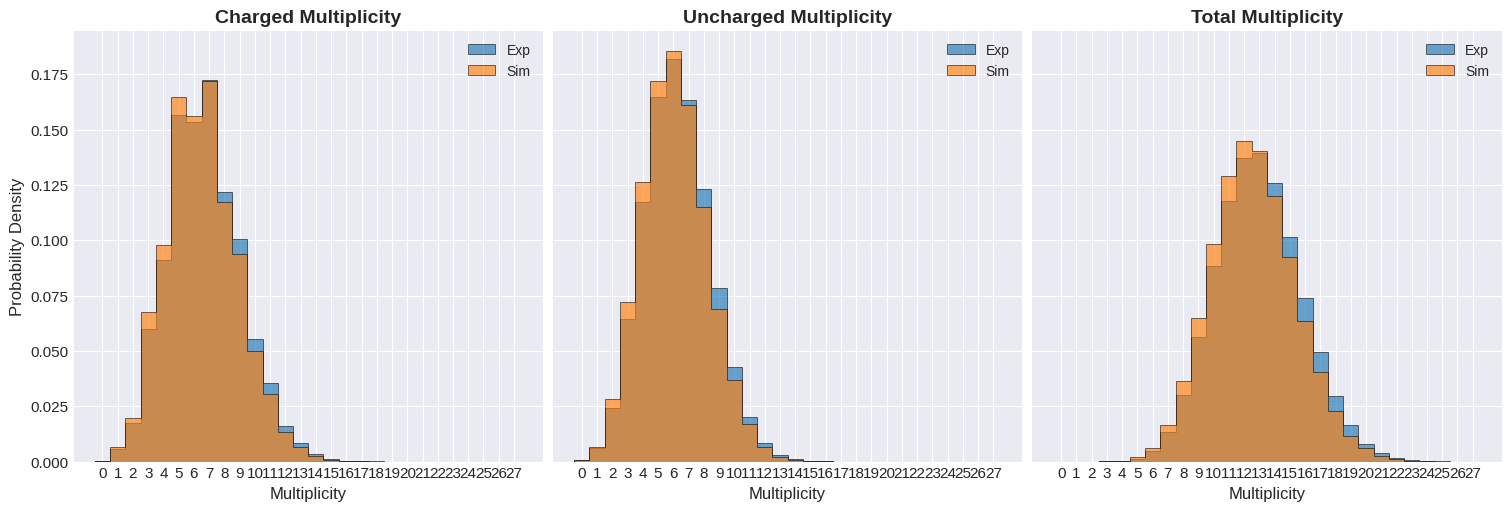

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# Collect all multiplicity arrays to determine common integer bin range
all_mult = [
    np.asarray(charged_mult_exp),
    np.asarray(charged_mult_sim),
    np.asarray(uncharged_mult_exp),
    np.asarray(uncharged_mult_sim),
    np.asarray(exp_mult),
    np.asarray(sim_mult),
]

# Global integer min/max
gmin = int(min(a.min() for a in all_mult))
gmax = int(max(a.max() for a in all_mult))

# Bin edges at half-integers -> bars centered on integers, touching each other
bins = np.arange(gmin, gmax + 2) - 0.5  # +2 so the last integer gets a full bin

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)

hist_kwargs = dict(bins=bins, density=True, alpha=0.65,
                   histtype='stepfilled', edgecolor='black', linewidth=0.6)

# Charged multiplicity
axs[0].hist(charged_mult_exp, color="C0", label="Exp", **hist_kwargs)
axs[0].hist(charged_mult_sim, color="C1", label="Sim", **hist_kwargs)
axs[0].set_title('Charged Multiplicity', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Multiplicity', fontsize=12)
axs[0].set_ylabel('Probability Density', fontsize=12)
axs[0].legend()

# Uncharged multiplicity
axs[1].hist(uncharged_mult_exp, color="C0", label="Exp", **hist_kwargs)
axs[1].hist(uncharged_mult_sim, color="C1", label="Sim", **hist_kwargs)
axs[1].set_title('Uncharged Multiplicity', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Multiplicity', fontsize=12)
axs[1].legend()

# Total multiplicity
axs[2].hist(exp_mult, color="C0", label="Exp", **hist_kwargs)
axs[2].hist(sim_mult, color="C1", label="Sim", **hist_kwargs)
axs[2].set_title('Total Multiplicity', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Multiplicity', fontsize=12)
axs[2].legend()

# Integer x-ticks for all axes
xticks = np.arange(gmin, gmax + 1, max(1, (gmax - gmin) // 10 or 1))  # dense but reasonable
for ax in axs:
    ax.set_xticks(np.arange(gmin, gmax + 1))  # exact integers
    ax.tick_params(axis='both', which='major', labelsize=11)

plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/observables/multiplicity_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:

# # p_frac_exp: shape (n_events, n_particles) with per-event fractions (e.g., |p_i| / sum |p|).
# # charged_mask_exp: boolean mask of same shape (True where particle is charged, False otherwise).

# mask = charged_mask_exp.astype(bool)

# # counts per event (how many charged entries)
# counts = np.sum(mask, axis=1, keepdims=True)  # shape (n_events, 1)

# # avoid div-by-zero
# safe = counts > 0

# # ---- First raw moment (mean) over charged particles: m1 = <z>_charged
# m1 = np.zeros_like(counts, dtype=float)
# m1[safe] = (np.sum(p_frac_exp * mask, axis=1, keepdims=True)[safe] /
#             counts[safe])                                       # shape (n_events,1)

# # ---- Second raw moment: m2 = <z^2>_charged
# m2 = np.zeros_like(counts, dtype=float)
# m2[safe] = (np.sum((p_frac_exp**2) * mask, axis=1, keepdims=True)[safe] /
#             counts[safe])

# # ---- Second central moment (variance): var = <(z - m1)^2>_charged
# var = np.zeros_like(counts, dtype=float)
# var[safe] = (np.sum(((p_frac_exp - m1)**2) * mask, axis=1, keepdims=True)[safe] /
#              counts[safe])

# # If you want 1D arrays:
# p_charged_1mom_frac_exp = m1.ravel()
# p_charged_2raw_frac_exp = m2.ravel()
# p_charged_var_frac_exp  = var.ravel()

# print("mean (m1):", p_charged_1mom_frac_exp)
# print("2nd raw (m2):", p_charged_2raw_frac_exp)
# print("variance:", p_charged_var_frac_exp)

In [15]:
import numpy as np

def momentum_fraction_moments(p_frac, charged_mask):
    """
    Compute first 3 moments (mean, variance, skewness) of momentum fractions
    for the charged subset of particles in each event.

    Parameters
    ----------
    p_frac : array, shape (n_events, n_particles)
        Momentum fractions per event (e.g., |p_i| / sum|p|).
    charged_mask : bool array of same shape
        True where particle is charged, False otherwise.

    Returns
    -------
    mean : (n_events,) array
        First moment (mean) over charged subset.
    m2_raw : (n_events,) array
        Second raw moment <z^2>.
    var : (n_events,) array
        Variance <(z - mean)^2>.
    skew : (n_events,) array
        Skewness (third central moment normalized by variance^(3/2)).
    """
    mask = charged_mask.astype(bool)
    counts = np.sum(mask, axis=1, keepdims=True)
    safe = counts > 0
    eps = 1e-12

    # First moment <z>
    m1 = np.zeros_like(counts, dtype=float)
    m1[safe] = np.sum(p_frac * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Second raw moment <z^2>
    m2_raw = np.zeros_like(counts, dtype=float)
    m2_raw[safe] = np.sum((p_frac**2) * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Variance <(z - m1)^2>
    var = np.zeros_like(counts, dtype=float)
    var[safe] = np.sum(((p_frac - m1)**2) * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Skewness
    skew = np.zeros_like(counts, dtype=float)
    skew[safe] = np.sum((((p_frac - m1) / (np.sqrt(var) + eps))**3) * mask,
                         axis=1, keepdims=True)[safe] / counts[safe]

    return m1.ravel(), m2_raw.ravel(), var.ravel(), skew.ravel()


# --- Experimental data ---
p_charged_1mom_exp, p_charged_2raw_exp, p_charged_var_exp, p_charged_skew_exp = \
    momentum_fraction_moments(p_frac_exp, charged_mask_exp)

# --- Simulated data ---
p_charged_1mom_sim, p_charged_2raw_sim, p_charged_var_sim, p_charged_skew_sim = \
    momentum_fraction_moments(p_frac_sim, charged_mask_sim)

# Debug print
print("Experimental mean (m1):", p_charged_1mom_exp)
print("Experimental variance :", p_charged_var_exp)
print("Experimental skewness :", p_charged_skew_exp)

print("Simulated mean (m1):", p_charged_1mom_sim)
print("Simulated variance :", p_charged_var_sim)
print("Simulated skewness :", p_charged_skew_sim)


Experimental mean (m1): [0.03859143 0.03864934 0.03005743 ... 0.06386959 0.05664617 0.01596849]
Experimental variance : [0.00220354 0.00195395 0.00178536 ... 0.00915586 0.00236079 0.00018309]
Experimental skewness : [1.34970167 1.51407139 1.7257382  ... 1.43096145 0.78200914 0.85376178]
Simulated mean (m1): [0.04078062 0.03071238 0.03811553 ... 0.14373278 0.11087997 0.14341341]
Simulated variance : [0.00183092 0.00126977 0.00176685 ... 0.00196001 0.00939009 0.05991878]
Simulated skewness : [1.29003348e+00 1.39812905e+00 1.23357495e+00 ... 4.99600361e-16
 7.65055287e-01 1.67456856e+00]


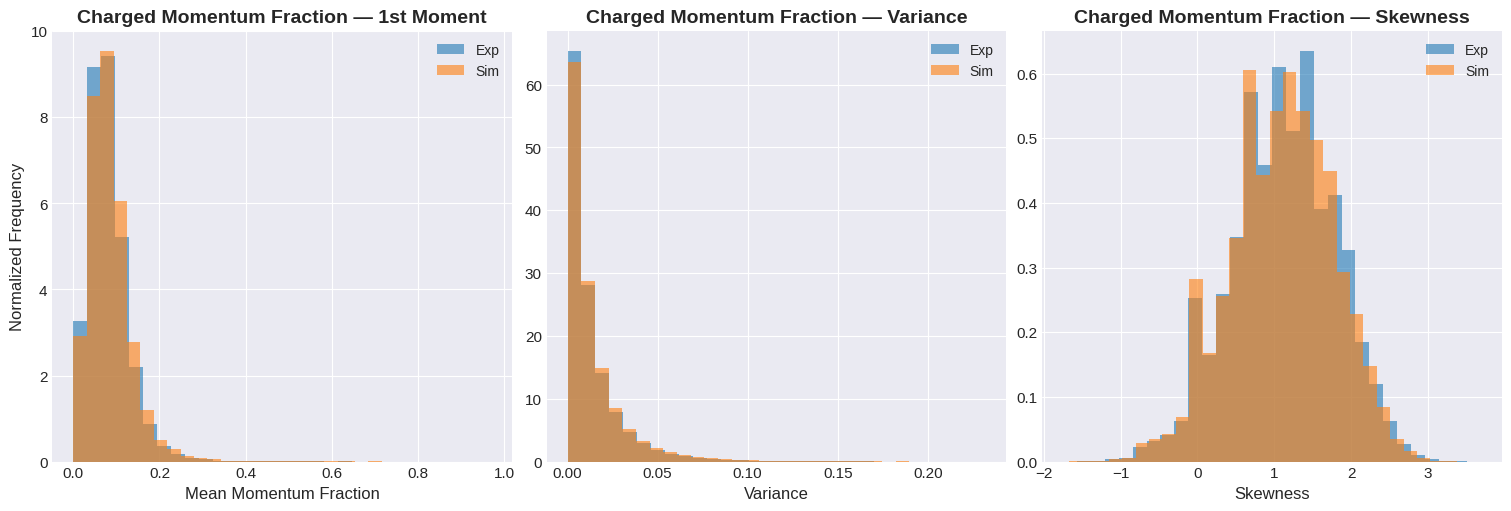

In [29]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
bins = 30

# Panel 1 — First moment (mean)
axs[0].hist(p_charged_1mom_exp, bins=bins, alpha=0.6, density=True, color="C0", label="Exp")
axs[0].hist(p_charged_1mom_sim, bins=bins, alpha=0.6, density=True, color="C1", label="Sim")
axs[0].set_title("Charged Momentum Fraction — 1st Moment", fontsize=14, fontweight="bold")
axs[0].set_xlabel("Mean Momentum Fraction", fontsize=12)
axs[0].set_ylabel("Normalized Frequency", fontsize=12)
axs[0].legend()

# Panel 2 — Second moment (variance)
axs[1].hist(p_charged_var_exp, bins=bins, alpha=0.6, density=True, color="C0", label="Exp")
axs[1].hist(p_charged_var_sim, bins=bins, alpha=0.6, density=True, color="C1", label="Sim")
axs[1].set_title("Charged Momentum Fraction — Variance", fontsize=14, fontweight="bold")
axs[1].set_xlabel("Variance", fontsize=12)
axs[1].legend()

# Panel 3 — Third moment (skewness)
axs[2].hist(p_charged_skew_exp, bins=bins, alpha=0.6, density=True, color="C0", label="Exp")
axs[2].hist(p_charged_skew_sim, bins=bins, alpha=0.6, density=True, color="C1", label="Sim")
axs[2].set_title("Charged Momentum Fraction — Skewness", fontsize=14, fontweight="bold")
axs[2].set_xlabel("Skewness", fontsize=12)
axs[2].legend()

# Make tick labels slightly bigger
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=11)

plt.show()


In [27]:
# Mask for all real particles (exclude padding)
all_mask_exp = pid_exp != 0
all_mask_sim = pid_sim != 0

p_all_1mom_exp, p_all_2raw_exp, p_all_var_exp, p_all_skew_exp = \
    momentum_fraction_moments(p_frac_exp, all_mask_exp)

p_all_1mom_sim, p_all_2raw_sim, p_all_var_sim, p_all_skew_sim = \
    momentum_fraction_moments(p_frac_sim, all_mask_sim)


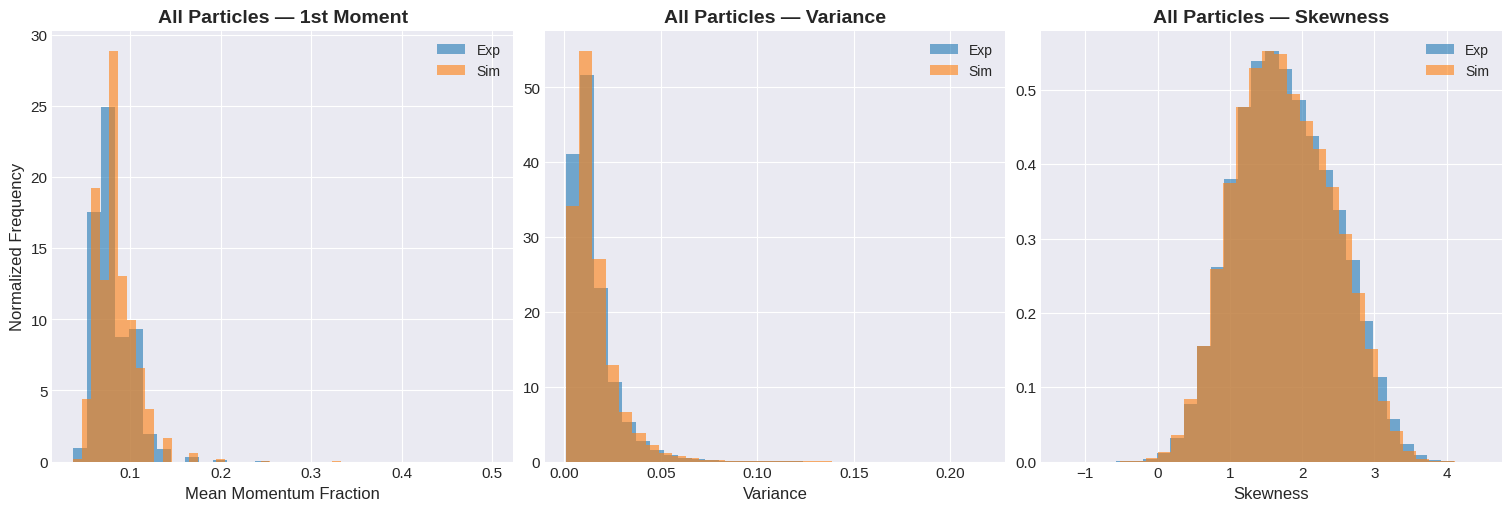

In [28]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Panel 1 — First moment (mean)
axs[0].hist(p_all_1mom_exp, bins=30, alpha=0.6, density=True, color="C0", label="Exp")
axs[0].hist(p_all_1mom_sim, bins=30, alpha=0.6, density=True, color="C1", label="Sim")
axs[0].set_title("All Particles — 1st Moment", fontsize=14, fontweight="bold")
axs[0].set_xlabel("Mean Momentum Fraction", fontsize=12)
axs[0].set_ylabel("Normalized Frequency", fontsize=12)
axs[0].legend()

# Panel 2 — Second moment (variance)
axs[1].hist(p_all_var_exp, bins=30, alpha=0.6, density=True, color="C0", label="Exp")
axs[1].hist(p_all_var_sim, bins=30, alpha=0.6, density=True, color="C1", label="Sim")
axs[1].set_title("All Particles — Variance", fontsize=14, fontweight="bold")
axs[1].set_xlabel("Variance", fontsize=12)
axs[1].legend()

# Panel 3 — Third moment (skewness)
axs[2].hist(p_all_skew_exp, bins=30, alpha=0.6, density=True, color="C0", label="Exp")
axs[2].hist(p_all_skew_sim, bins=30, alpha=0.6, density=True, color="C1", label="Sim")
axs[2].set_title("All Particles — Skewness", fontsize=14, fontweight="bold")
axs[2].set_xlabel("Skewness", fontsize=12)
axs[2].legend()

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=11)

plt.show()
